# **Data Preparation**

## **Install Packages**

In [ ]:
!pip install -q -U gensim openpyxl emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 46.9 MB/s eta 0:00:00


* **genism** trains FastText and Word2Vec and loads GloVe
* **openpyal** allows pandas to load Excel files
* **emoji** converts preserved emoji into readable tokens for embedding training

## **Mount Google Drive**

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## **Import Libraries**

In [ ]:
import os
import re
import gc
import random
import warnings

import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.sparse import csr_matrix, hstack

from gensim.models import FastText, Word2Vec
import gensim.downloader as gensim_api

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

## **Set Random Seeds**

In [ ]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


- The random seed makes data splitting and model initialization more consistent across repeated notebook runs

## **Set Dataset Paths**

In [ ]:
TFIDF_DATASET_PATH = (
    "/content/drive/MyDrive/spotify_preprocessed_output/""spotify_reviews_tfidf_dataset.csv"
)

EMBEDDING_DATASET_PATH = (
    "/content/drive/MyDrive/spotify_preprocessed_output/""spotify_reviews_embedding_dataset.csv"
)

## **Load Both Datasets**

In [ ]:
def load_table(file_path: str) -> pd.DataFrame:
    """
    Load either an Excel or CSV dataset.
    """
    extension = os.path.splitext(file_path)[1].lower()

    if extension in {".xlsx", ".xls"}:
        return pd.read_excel(file_path)

    if extension == ".csv":
        return pd.read_csv(file_path)

    raise ValueError(
        "Unsupported file type. Use CSV, XLS, or XLSX."
    )


tfidf_df = load_table(TFIDF_DATASET_PATH)
embedding_df = load_table(EMBEDDING_DATASET_PATH)

print("TF-IDF dataset shape:", tfidf_df.shape)
print("Embedding dataset shape:", embedding_df.shape)

display(tfidf_df.head())
display(embedding_df.head())

TF-IDF dataset shape: (65978, 5)
Embedding dataset shape: (65978, 5)


,global_index_id,custom_id,review_text,rating_score,rating_scale
0,review_1,ds1_1,perfect,5,positive
1,review_2,ds1_2,nice app,1,negative
2,review_3,ds1_3,using mostly for bible podcast n prayers. very...,5,positive
3,review_4,ds1_4,it understands music taste and quality of soun...,5,positive
4,review_5,ds1_5,its very helpful especially to music lovers li...,5,positive


,global_index_id,custom_id,review_text,rating_score,rating_scale
0,review_1,ds1_1,perfect,5,positive
1,review_2,ds1_2,nice app,1,negative
2,review_3,ds1_3,using mostly for bible podcast n prayers. very...,5,positive
3,review_4,ds1_4,it understands music taste and quality of soun...,5,positive
4,review_5,ds1_5,its very helpful especially to music lovers li...,5,positive


## **Check Required Columns**

In [ ]:
REQUIRED_COLUMNS = {
    "global_index_id",
    "review_text",
    "rating_scale",
}

for dataset_name, dataset in {
    "TF-IDF": tfidf_df,
    "Embedding": embedding_df,
}.items():

    missing_columns = REQUIRED_COLUMNS - set(dataset.columns)

    if missing_columns:
        raise ValueError(
            f"{dataset_name} dataset is missing: "
            f"{sorted(missing_columns)}"
        )

print("All required columns are available.")

All required columns are available.


The hybrid process requires:
* **global_index_id** to align the same review across both dataset
* **review_text** as the model input
* **rating_scale** as the sentiment label

## **Align Two Datasets**

In [ ]:
if tfidf_df["global_index_id"].duplicated().any():
    raise ValueError(
        "Duplicate global_index_id found in TF-IDF dataset."
    )

if embedding_df["global_index_id"].duplicated().any():
    raise ValueError(
        "Duplicate global_index_id found in embedding dataset."
    )


tfidf_part = (
    tfidf_df[
        [
            "global_index_id",
            "review_text",
            "rating_scale",
        ]
    ]
    .rename(
        columns={
            "review_text": "text_tfidf",
            "rating_scale": "label_tfidf",
        }
    )
)

embedding_part = (
    embedding_df[
        [
            "global_index_id",
            "review_text",
            "rating_scale",
        ]
    ]
    .rename(
        columns={
            "review_text": "text_embedding",
            "rating_scale": "label_embedding",
        }
    )
)


data = tfidf_part.merge(
    embedding_part,
    on="global_index_id",
    how="inner",
    validate="one_to_one",
)

data["label_tfidf"] = (
    data["label_tfidf"]
    .astype(str)
    .str.lower()
    .str.strip()
)

data["label_embedding"] = (
    data["label_embedding"]
    .astype(str)
    .str.lower()
    .str.strip()
)


label_mismatch = (
    data["label_tfidf"]
    != data["label_embedding"]
)

if label_mismatch.any():
    raise ValueError(
        f"{label_mismatch.sum()} records have different labels "
        "between the two datasets."
    )


data["label"] = data["label_tfidf"]

data = data[
    [
        "global_index_id",
        "text_tfidf",
        "text_embedding",
        "label",
    ]
].copy()

print("Aligned dataset shape:", data.shape)
display(data.head())

Aligned dataset shape: (65978, 4)


,global_index_id,text_tfidf,text_embedding,label
0,review_1,perfect,perfect,positive
1,review_2,nice app,nice app,negative
2,review_3,using mostly for bible podcast n prayers. very...,using mostly for bible podcast n prayers. very...,positive
3,review_4,it understands music taste and quality of soun...,it understands music taste and quality of soun...,positive
4,review_5,its very helpful especially to music lovers li...,its very helpful especially to music lovers li...,positive


The merge ensures the TF-IDF text and Embedding text in each row refer to the same original review. Without alignment, one review could accidentally receive features from another review, making the experiment invalid.

## **Remove Neutral Reviews**

In [ ]:
data = data[
    data["label"].isin(
        [
            "negative",
            "positive",
        ]
    )
].copy()

data = data.dropna(
    subset=[
        "text_tfidf",
        "text_embedding",
        "label",
    ]
)

data["text_tfidf"] = (
    data["text_tfidf"]
    .astype(str)
    .str.strip()
)

data["text_embedding"] = (
    data["text_embedding"]
    .astype(str)
    .str.strip()
)

data = data[
    data["text_tfidf"].ne("")
    & data["text_embedding"].ne("")
].reset_index(drop=True)

print("Binary dataset shape:", data.shape)

print("\nBinary class distribution:")
print(data["label"].value_counts())

Binary dataset shape: (65978, 4)

Binary class distribution:
label
positive    37548
negative    28430
Name: count, dtype: int64


## **Perform One Shared 80:10:10 Split**

In [ ]:
train_df, temporary_df = train_test_split(
    data,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=data["label"],
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=temporary_df["label"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training records:", len(train_df))
print("Validation records:", len(validation_df))
print("Test records:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=True))

Training records: 52782
Validation records: 6598
Test records: 6598

Training distribution:
label
positive    0.569096
negative    0.430904
Name: proportion, dtype: float64

Validation distribution:
label
positive    0.569112
negative    0.430888
Name: proportion, dtype: float64

Test distribution:
label
positive    0.569112
negative    0.430888
Name: proportion, dtype: float64


A single shared split makes all six hybrid experiment fair. The same reviews appear in the training, validation, and test subsets for every representation.

## **Encode the Binary Labels**

In [ ]:
LABEL_MAP = {
    "negative": 0,
    "positive": 1,
}

y_train = (
    train_df["label"]
    .map(LABEL_MAP)
    .to_numpy(dtype=np.int32)
)

y_validation = (
    validation_df["label"]
    .map(LABEL_MAP)
    .to_numpy(dtype=np.int32)
)

y_test = (
    test_df["label"]
    .map(LABEL_MAP)
    .to_numpy(dtype=np.int32)
)

print("Label mapping:", LABEL_MAP)

print(
    "Training labels:",
    np.bincount(y_train),
)

Label mapping: {'negative': 0, 'positive': 1}
Training labels: [22744 30038]


The sentiment labels are converted into the numerical format required by Logistic Regression and LSTM

## **Calculate Class Weights**

In [ ]:
classes = np.unique(y_train)

calculated_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

CLASS_WEIGHT_DICT = {
    int(class_label): float(weight)
    for class_label, weight
    in zip(classes, calculated_weights)
}

print("Class weights:", CLASS_WEIGHT_DICT)

Class weights: {0: 1.1603499824129442, 1: 0.8785871229775618}


The minority class receives a larger learning weight. Class weights are used for all hybrid models instead of SMOTE because these experiments contain embedding features as part of the fused representation.

## **Create an Evaluation Function**

In [ ]:
def evaluate_binary_model(
    y_true,
    y_pred,
    title: str,
    show_matrix: bool = True,
):
    """
    Display binary classification results.
    """

    results = {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }

    print(f"\n=== {title} ===")

    for metric_name, metric_value in results.items():
        print(
            f"{metric_name}: "
            f"{metric_value:.4f}"
        )

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "negative",
                "positive",
            ],
            digits=4,
            zero_division=0,
        )
    )

    if show_matrix:
        ConfusionMatrixDisplay.from_predictions(
            y_true,
            y_pred,
            display_labels=[
                "negative",
                "positive",
            ],
            values_format="d",
        )

        plt.title(title)
        plt.tight_layout()
        plt.show()

    return results

All models are evaluated consistently using:
* Accuracy
* Weighted Precision
* Weighted Recall
* Weighted F1-score
* Macro F1-score
* Confusion Matrix

# **Logistic Regression Hybrid Models**

## **Tokenize Embedding Text**

In [ ]:
EMBEDDING_TOKEN_PATTERN = re.compile(
    r"emoji_[a-z0-9_]+|[a-z]+(?:'[a-z]+)?"
)


def tokenize_embedding_text(text: str) -> list[str]:
    """
    Convert preserved emoji to names and extract word tokens.
    """
    text = emoji.demojize(
        str(text).lower(),
        delimiters=(
            " emoji_",
            " ",
        ),
    )

    return EMBEDDING_TOKEN_PATTERN.findall(text)


train_tokens = (
    train_df["text_embedding"]
    .apply(tokenize_embedding_text)
    .tolist()
)

validation_tokens = (
    validation_df["text_embedding"]
    .apply(tokenize_embedding_text)
    .tolist()
)

test_tokens = (
    test_df["text_embedding"]
    .apply(tokenize_embedding_text)
    .tolist()
)

print("Example tokens:")
print(train_tokens[0])

Example tokens:
['i', 'joined', 'spotify', 'for', 'the', 'music', 'but', 'i', 'increasingly', 'use', 'it', 'for', 'podcasts', 'and', 'news', 'shows', 'i', 'have', 'learned', 'about', 'many', 'new', 'artists', 'and', 'podcasts', 'through', "spotify's", 'algorithms', 'and', 'i', 'am', 'very', 'grateful', 'for', 'that', 'it', 'is', 'hard', 'for', 'me', 'to', 'imagine', 'life', 'without', 'spotify', 'i', 'am', 'on', 'it', 'every', 'single', 'day', 'having', 'said', 'that', 'there', 'are', 'still', 'some', 'gaps', 'in', 'the', 'music', 'and', 'i', 'wish', 'spotify', 'would', 'be', 'more', 'proactive', 'in', 'closing', 'these', 'instead', 'of', 'telling', 'customers', 'to', 'contact', 'record', 'labels', 'to', 'tell', 'them', 'to', 'upload', 'an', 'album']


All embedding methods require tokenized words. Preserved emoji are converted into tokens such as **emoji_smiling_face**, allowing them to participate in embedding training instead of being discarded.

## **Train FastText and Word2Vec**

In [ ]:
EMBEDDING_DIM = 300

print("Training FastText...")

fasttext_model = FastText(
    sentences=train_tokens,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    sg=1,
    epochs=10,
    workers=4,
    seed=SEED,
)

print("Training Word2Vec...")

word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    sg=1,
    epochs=10,
    workers=4,
    seed=SEED,
)

print("FastText vocabulary:", len(fasttext_model.wv))
print("Word2Vec vocabulary:", len(word2vec_model.wv))

Training FastText...
Training Word2Vec...
FastText vocabulary: 10425
Word2Vec vocabulary: 10425


Both embedding models are trained only on the training reviews:
* **vector_size=300** generates 300-dimensional word vectors
* **window=5** uses nearby words as context
* **min_count=2** removes words appearing only once
* **sg=1** uses the skip-gram architecture
* **epochs=10** repeats training ten times

## **Load GloVe**

In [ ]:
GLOVE_MODEL_NAME = "glove-wiki-gigaword-300"

print("Loading GloVe...")
print("The first run may take several minutes.")

glove_vectors = gensim_api.load(
    GLOVE_MODEL_NAME
)

print("GloVe vocabulary:", len(glove_vectors))
print("GloVe dimension:", glove_vectors.vector_size)

Loading GloVe...
The first run may take several minutes.
[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe vocabulary: 400000
GloVe dimension: 300


## **Convert Each Review into One Embedding Vector**

In [ ]:
def create_average_document_vectors(
    token_lists,
    keyed_vectors,
    vector_size: int,
) -> np.ndarray:
    """
    Average the available word vectors in each review.
    """

    document_matrix = np.zeros(
        (
            len(token_lists),
            vector_size,
        ),
        dtype=np.float32,
    )

    for document_index, tokens in enumerate(token_lists):
        available_vectors = []

        for token in tokens:
            try:
                available_vectors.append(
                    keyed_vectors[token]
                )
            except KeyError:
                continue

        if available_vectors:
            document_matrix[document_index] = (
                np.mean(
                    available_vectors,
                    axis=0,
                )
            )

    return document_matrix

Logistic Regression requires one fixed-length feature vector for each review. Therefore, all available word vectors in a review are averaged into one document-level vector.

## **Generate FastText, Word2Vec, and GloVe matrics**

In [ ]:
embedding_matrices = {}


print("Creating FastText document vectors...")

embedding_matrices["FastText"] = {
    "train": create_average_document_vectors(
        train_tokens,
        fasttext_model.wv,
        fasttext_model.vector_size,
    ),
    "validation": create_average_document_vectors(
        validation_tokens,
        fasttext_model.wv,
        fasttext_model.vector_size,
    ),
    "test": create_average_document_vectors(
        test_tokens,
        fasttext_model.wv,
        fasttext_model.vector_size,
    ),
}


print("Creating Word2Vec document vectors...")

embedding_matrices["Word2Vec"] = {
    "train": create_average_document_vectors(
        train_tokens,
        word2vec_model.wv,
        word2vec_model.vector_size,
    ),
    "validation": create_average_document_vectors(
        validation_tokens,
        word2vec_model.wv,
        word2vec_model.vector_size,
    ),
    "test": create_average_document_vectors(
        test_tokens,
        word2vec_model.wv,
        word2vec_model.vector_size,
    ),
}


print("Creating GloVe document vectors...")

embedding_matrices["GloVe"] = {
    "train": create_average_document_vectors(
        train_tokens,
        glove_vectors,
        glove_vectors.vector_size,
    ),
    "validation": create_average_document_vectors(
        validation_tokens,
        glove_vectors,
        glove_vectors.vector_size,
    ),
    "test": create_average_document_vectors(
        test_tokens,
        glove_vectors,
        glove_vectors.vector_size,
    ),
}


for embedding_name, matrices in embedding_matrices.items():
    print(
        embedding_name,
        matrices["train"].shape,
        matrices["validation"].shape,
        matrices["test"].shape,
    )

Creating FastText document vectors...
Creating Word2Vec document vectors...
Creating GloVe document vectors...
FastText (52782, 300) (6598, 300) (6598, 300)
Word2Vec (52782, 300) (6598, 300) (6598, 300)
GloVe (52782, 300) (6598, 300) (6598, 300)


This produces separate dense feature matrices for:
* FastText
* Word2Vec
* GloVe

All matrices retain exactly the same row order as the TF-IDF training, validation, and text subsets

## **Create TF-IDF Unigram + Bigram + Trigram Features**

In [ ]:
lr_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=20000,
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

X_train_tfidf_123 = (
    lr_tfidf_vectorizer.fit_transform(
        train_df["text_tfidf"]
    )
)

X_validation_tfidf_123 = (
    lr_tfidf_vectorizer.transform(
        validation_df["text_tfidf"]
    )
)

X_test_tfidf_123 = (
    lr_tfidf_vectorizer.transform(
        test_df["text_tfidf"]
    )
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf_123.shape,
)

print(
    "Validation TF-IDF shape:",
    X_validation_tfidf_123.shape,
)

print(
    "Test TF-IDF shape:",
    X_test_tfidf_123.shape,
)

Training TF-IDF shape: (52782, 20000)
Validation TF-IDF shape: (6598, 20000)
Test TF-IDF shape: (6598, 20000)


The vectorizer is fitted only on the training text to prevent validation or test vocabulary from entering the model.

## **Define Logistic Regression hybrid training function**

In [ ]:
LR_C_VALUES = [
    0.1,
    1.0,
    10.0,
]


def train_logistic_hybrid(
    embedding_name: str,
    embedding_data: dict,
):
    """
    Concatenate TF-IDF (1,3) with one embedding
    representation and train Logistic Regression.
    """

    embedding_scaler = StandardScaler()

    X_train_embedding_scaled = (
        embedding_scaler.fit_transform(
            embedding_data["train"]
        ).astype(np.float32)
    )

    X_validation_embedding_scaled = (
        embedding_scaler.transform(
            embedding_data["validation"]
        ).astype(np.float32)
    )

    X_train_hybrid = hstack(
        [
            X_train_tfidf_123,
            csr_matrix(
                X_train_embedding_scaled
            ),
        ],
        format="csr",
    )

    X_validation_hybrid = hstack(
        [
            X_validation_tfidf_123,
            csr_matrix(
                X_validation_embedding_scaled
            ),
        ],
        format="csr",
    )

    print(
        f"\n{embedding_name} hybrid shape:",
        X_train_hybrid.shape,
    )

    best_model = None
    best_c = None
    best_validation_f1 = -1.0

    for c_value in LR_C_VALUES:
        model = LogisticRegression(
            C=c_value,
            solver="saga",
            penalty="l2",
            class_weight="balanced",
            max_iter=2000,
            random_state=SEED,
        )

        model.fit(
            X_train_hybrid,
            y_train,
        )

        validation_predictions = model.predict(
            X_validation_hybrid
        )

        validation_f1 = f1_score(
            y_validation,
            validation_predictions,
            average="weighted",
            zero_division=0,
        )

        validation_accuracy = accuracy_score(
            y_validation,
            validation_predictions,
        )

        print(
            f"C={c_value:<4} | "
            f"Accuracy={validation_accuracy:.4f} | "
            f"Weighted F1={validation_f1:.4f}"
        )

        if validation_f1 > best_validation_f1:
            best_model = model
            best_c = c_value
            best_validation_f1 = validation_f1

    best_validation_predictions = (
        best_model.predict(
            X_validation_hybrid
        )
    )

    validation_metrics = evaluate_binary_model(
        y_validation,
        best_validation_predictions,
        title=(
            "Logistic Regression + TF-IDF (1,3) "
            f"+ {embedding_name} — Validation"
        ),
    )

    return {
        "embedding_name": embedding_name,
        "model": best_model,
        "scaler": embedding_scaler,
        "best_c": best_c,
        "validation_metrics": validation_metrics,
    }

Functions include:
1. Standardises the embedding dimensions
2. Converts the embedding vectors into sparse format
3. Concatenates them with TF-IDF
4. Tests several regularisation strengths
5. Selects the best version using validation weighted F1-score

The **saga** solver is suitable for larger sparse feature spaces, but its convergence benefits from scaled features, which is why the embedding block is standardized first.

## **Train the three Logistic Regression Hybrids separately**

### **TF-IDF + FastText**


FastText hybrid shape: (52782, 20300)
C=0.1  | Accuracy=0.8938 | Weighted F1=0.8942
C=1.0  | Accuracy=0.9033 | Weighted F1=0.9037
C=10.0 | Accuracy=0.9033 | Weighted F1=0.9037

=== Logistic Regression + TF-IDF (1,3) + FastText — Validation ===
accuracy: 0.9033
precision_weighted: 0.9067
recall_weighted: 0.9033
f1_weighted: 0.9037
f1_macro: 0.9023

Classification Report:

              precision    recall  f1-score   support

    negative     0.8562    0.9321    0.8926      2843
    positive     0.9449    0.8815    0.9121      3755

    accuracy                         0.9033      6598
   macro avg     0.9006    0.9068    0.9023      6598
weighted avg     0.9067    0.9033    0.9037      6598



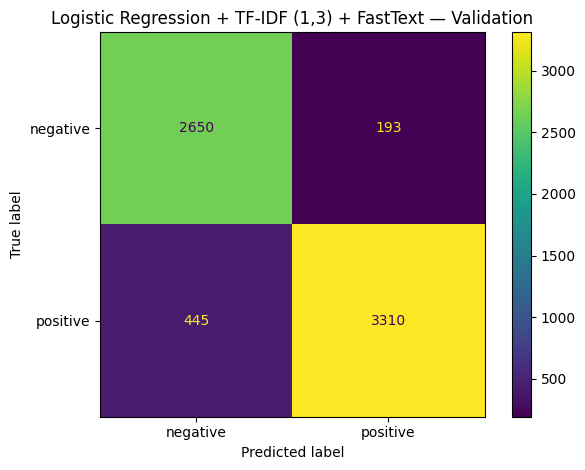

In [ ]:
lr_fasttext_result = train_logistic_hybrid(
    embedding_name="FastText",
    embedding_data=embedding_matrices["FastText"],
)

### **TF-IDF + Word2Vec**


Word2Vec hybrid shape: (52782, 20300)
C=0.1  | Accuracy=0.8939 | Weighted F1=0.8944
C=1.0  | Accuracy=0.9032 | Weighted F1=0.9035
C=10.0 | Accuracy=0.9032 | Weighted F1=0.9035

=== Logistic Regression + TF-IDF (1,3) + Word2Vec — Validation ===
accuracy: 0.9032
precision_weighted: 0.9062
recall_weighted: 0.9032
f1_weighted: 0.9035
f1_macro: 0.9021

Classification Report:

              precision    recall  f1-score   support

    negative     0.8580    0.9289    0.8921      2843
    positive     0.9426    0.8836    0.9122      3755

    accuracy                         0.9032      6598
   macro avg     0.9003    0.9063    0.9021      6598
weighted avg     0.9062    0.9032    0.9035      6598



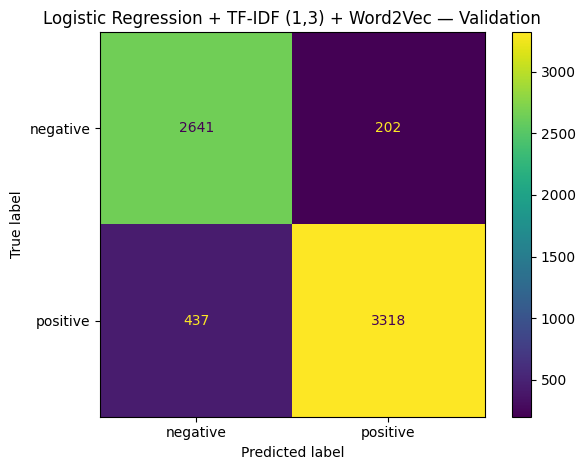

In [ ]:
lr_word2vec_result = train_logistic_hybrid(
    embedding_name="Word2Vec",
    embedding_data=embedding_matrices["Word2Vec"],
)

### **TF-IDF + GloVe**


GloVe hybrid shape: (52782, 20300)
C=0.1  | Accuracy=0.8800 | Weighted F1=0.8805
C=1.0  | Accuracy=0.8978 | Weighted F1=0.8983
C=10.0 | Accuracy=0.8978 | Weighted F1=0.8983

=== Logistic Regression + TF-IDF (1,3) + GloVe — Validation ===
accuracy: 0.8978
precision_weighted: 0.9017
recall_weighted: 0.8978
f1_weighted: 0.8983
f1_macro: 0.8969

Classification Report:

              precision    recall  f1-score   support

    negative     0.8482    0.9293    0.8869      2843
    positive     0.9423    0.8740    0.9069      3755

    accuracy                         0.8978      6598
   macro avg     0.8952    0.9017    0.8969      6598
weighted avg     0.9017    0.8978    0.8983      6598



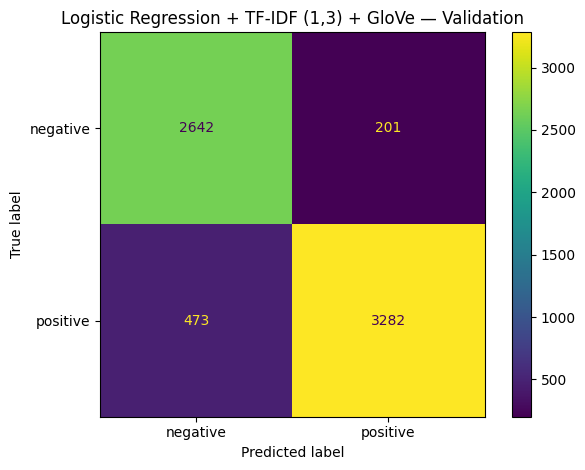

In [ ]:
lr_glove_result = train_logistic_hybrid(
    embedding_name="GloVe",
    embedding_data=embedding_matrices["GloVe"],
)

## **Comparison of Logistic Regression Validation Results**

In [ ]:
lr_results = {
    "FastText": lr_fasttext_result,
    "Word2Vec": lr_word2vec_result,
    "GloVe": lr_glove_result,
}

lr_validation_summary = pd.DataFrame(
    [
        {
            "Hybrid Model": (
                "Logistic Regression + TF-IDF (1,3) "
                f"+ {embedding_name}"
            ),
            "Best C": result["best_c"],
            "Accuracy": (
                result["validation_metrics"]["accuracy"]
            ),
            "Weighted F1": (
                result["validation_metrics"]["f1_weighted"]
            ),
            "Macro F1": (
                result["validation_metrics"]["f1_macro"]
            ),
        }
        for embedding_name, result
        in lr_results.items()
    ]
).sort_values(
    by="Weighted F1",
    ascending=False,
)

display(lr_validation_summary)

,Hybrid Model,Best C,Accuracy,Weighted F1,Macro F1
0,"Logistic Regression + TF-IDF (1,3) + FastText",1.0,0.903304,0.903677,0.902327
1,"Logistic Regression + TF-IDF (1,3) + Word2Vec",1.0,0.903152,0.903510,0.902122
2,"Logistic Regression + TF-IDF (1,3) + GloVe",1.0,0.897848,0.898260,0.896878


# **LSTM + Word2Vec + TF-IDF Hybrids**

## **Prepare Tokenized Strings for LSTM**

In [ ]:
train_embedding_texts = np.asarray(
    [
        " ".join(tokens)
        for tokens in train_tokens
    ],
    dtype=str,
)

validation_embedding_texts = np.asarray(
    [
        " ".join(tokens)
        for tokens in validation_tokens
    ],
    dtype=str,
)

test_embedding_texts = np.asarray(
    [
        " ".join(tokens)
        for tokens in test_tokens
    ],
    dtype=str,
)

print(train_embedding_texts[0])

i joined spotify for the music but i increasingly use it for podcasts and news shows i have learned about many new artists and podcasts through spotify's algorithms and i am very grateful for that it is hard for me to imagine life without spotify i am on it every single day having said that there are still some gaps in the music and i wish spotify would be more proactive in closing these instead of telling customers to contact record labels to tell them to upload an album


LSTM requires ordered word sequences instead of averaged document vectors. Therefore, the token order is preserved.

## **Determine Sequence Length**

In [ ]:
training_lengths = np.asarray(
    [
        len(tokens)
        for tokens in train_tokens
    ]
)

MAX_SEQUENCE_LENGTH = int(
    np.percentile(
        training_lengths,
        95,
    )
)

MAX_SEQUENCE_LENGTH = max(
    20,
    min(
        MAX_SEQUENCE_LENGTH,
        200,
    ),
)

print(
    "Selected maximum sequence length:",
    MAX_SEQUENCE_LENGTH,
)

Selected maximum sequence length: 80


The 95th percentile covers most reviews without forcing every review to use the length of the longest record. The limit of 200 also controls memory usage.

## **Create Integer Sequence Vectorizer**

In [ ]:
MAX_TOKENS = 30000

sequence_vectorizer = (
    tf.keras.layers.TextVectorization(
        max_tokens=MAX_TOKENS,
        standardize=None,
        split="whitespace",
        output_mode="int",
        output_sequence_length=(
            MAX_SEQUENCE_LENGTH
        ),
        name="sequence_vectorizer",
    )
)

sequence_vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        train_embedding_texts
    ).batch(1024)
)

X_train_sequence = (
    sequence_vectorizer(
        train_embedding_texts
    )
    .numpy()
    .astype(np.int32)
)

X_validation_sequence = (
    sequence_vectorizer(
        validation_embedding_texts
    )
    .numpy()
    .astype(np.int32)
)

X_test_sequence = (
    sequence_vectorizer(
        test_embedding_texts
    )
    .numpy()
    .astype(np.int32)
)

print(
    "Training sequence shape:",
    X_train_sequence.shape,
)

Training sequence shape: (52782, 80)


**TextVectorization** learns the vocabulary from the training text and maps each review to a fixed-length integer sequence.

## **Force All Sequences to Use Right Padding**

In [ ]:
def find_invalid_padding_rows(
    sequences: np.ndarray
) -> np.ndarray:
    """
    Identify rows containing a zero-padding value
    before a later non-zero token.
    """

    non_padding_mask = sequences != 0

    zero_already_seen = np.maximum.accumulate(
        ~non_padding_mask,
        axis=1
    )

    invalid_rows = np.any(
        zero_already_seen & non_padding_mask,
        axis=1
    )

    return invalid_rows


def force_right_padding(
    sequences: np.ndarray
) -> np.ndarray:
    """
    Remove internal zero values and move all padding
    to the right side of each sequence.
    """

    corrected_sequences = np.zeros_like(
        sequences,
        dtype=np.int32
    )

    maximum_length = sequences.shape[1]

    for row_index, sequence in enumerate(sequences):

        valid_tokens = sequence[
            sequence != 0
        ]

        valid_tokens = valid_tokens[
            :maximum_length
        ]

        corrected_sequences[
            row_index,
            :len(valid_tokens)
        ] = valid_tokens

    return corrected_sequences

## **Check and Correct All Three Datasets**

In [ ]:
train_invalid_before = find_invalid_padding_rows(
    X_train_sequence
)

validation_invalid_before = find_invalid_padding_rows(
    X_validation_sequence
)

test_invalid_before = find_invalid_padding_rows(
    X_test_sequence
)

print(
    "Invalid training sequences before correction:",
    train_invalid_before.sum()
)

print(
    "Invalid validation sequences before correction:",
    validation_invalid_before.sum()
)

print(
    "Invalid test sequences before correction:",
    test_invalid_before.sum()
)

Invalid training sequences before correction: 0
Invalid validation sequences before correction: 0
Invalid test sequences before correction: 0


In [ ]:
X_train_sequence = force_right_padding(
    X_train_sequence
)

X_validation_sequence = force_right_padding(
    X_validation_sequence
)

X_test_sequence = force_right_padding(
    X_test_sequence
)

In [ ]:
for row_index in range(5):
    print(
        f"Sequence {row_index}:",
        X_train_sequence[row_index]
    )

Sequence 0: [   2 1974   18   14    3   11   19    2 2798   54    5   14  100    6
 1614  305    2   17 2094  126   92   93  213    6  100  225  990 1566
    6    2   41   52 1787   14   21    5    7  388   14   39    4 1254
  414  103   18    2   41   22    5   76  361  190  176  554   21   55
   36   95   98 4214   23    3   11    6    2  253   18   69   50   84
 8582   23  706  292  290   16  879  902    4 1257]
Sequence 1: [253   5  64  10  26 606  23 242 922  20  19   3   8 428   6   5   7 271
 105  46   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0]
Sequence 2: [ 453    7   10    3  152 1115   94   97    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0   

## **Build Word2Vec Embedding Matrix**

In [ ]:
sequence_vocabulary = (
    sequence_vectorizer.get_vocabulary()
)

sequence_vocabulary_size = len(
    sequence_vocabulary
)

word2vec_embedding_matrix = np.zeros(
    (
        sequence_vocabulary_size,
        word2vec_model.vector_size,
    ),
    dtype=np.float32,
)

matched_words = 0

for word_index, word in enumerate(
    sequence_vocabulary
):
    if word in word2vec_model.wv:
        word2vec_embedding_matrix[
            word_index
        ] = word2vec_model.wv[word]

        matched_words += 1

print(
    "Sequence vocabulary size:",
    sequence_vocabulary_size,
)

print(
    "Words matched with Word2Vec:",
    matched_words,
)

print(
    "Embedding matrix shape:",
    word2vec_embedding_matrix.shape,
)

Sequence vocabulary size: 21488
Words matched with Word2Vec: 10425
Embedding matrix shape: (21488, 300)


The matrix links each integer token produced by **TextVectorization** to its corresponding 300-dimensional Word2Vec vector.

## **Define Three TF-IDF Variants**

In [ ]:
TFIDF_VARIANTS = {
    "Unigram": {
        "ngram_range": (1, 1),
        "max_features": 10000,
    },
    "Unigram_Bigram": {
        "ngram_range": (1, 2),
        "max_features": 15000,
    },
    "Unigram_Bigram_Trigram": {
        "ngram_range": (1, 3),
        "max_features": 20000,
    },
}

SVD_COMPONENTS = 128

Three TF-IDF Representations:
* Unigram
* Unigram + Bigram
* Unigram + Bigram + Trigram

## **Create a function for TF-IDF and SVD Preparation**

In [ ]:
def prepare_tfidf_branch(
    ngram_range,
    max_features,
):
    """
    Fit TF-IDF on training text and reduce it
    with TruncatedSVD.
    """

    tfidf_vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=2,
        sublinear_tf=True,
        dtype=np.float32,
    )

    X_train_sparse = (
        tfidf_vectorizer.fit_transform(
            train_df["text_tfidf"]
        )
    )

    X_validation_sparse = (
        tfidf_vectorizer.transform(
            validation_df["text_tfidf"]
        )
    )

    X_test_sparse = (
        tfidf_vectorizer.transform(
            test_df["text_tfidf"]
        )
    )

    number_of_components = min(
        SVD_COMPONENTS,
        X_train_sparse.shape[1] - 1,
    )

    svd_model = TruncatedSVD(
        n_components=number_of_components,
        n_iter=7,
        random_state=SEED,
    )

    X_train_reduced = (
        svd_model.fit_transform(
            X_train_sparse
        )
        .astype(np.float32)
    )

    X_validation_reduced = (
        svd_model.transform(
            X_validation_sparse
        )
        .astype(np.float32)
    )

    X_test_reduced = (
        svd_model.transform(
            X_test_sparse
        )
        .astype(np.float32)
    )

    reduced_scaler = StandardScaler()

    X_train_reduced = (
        reduced_scaler.fit_transform(
            X_train_reduced
        )
        .astype(np.float32)
    )

    X_validation_reduced = (
        reduced_scaler.transform(
            X_validation_reduced
        )
        .astype(np.float32)
    )

    X_test_reduced = (
        reduced_scaler.transform(
            X_test_reduced
        )
        .astype(np.float32)
    )

    return {
        "vectorizer": tfidf_vectorizer,
        "svd": svd_model,
        "scaler": reduced_scaler,
        "train": X_train_reduced,
        "validation": X_validation_reduced,
        "test": X_test_reduced,
    }

Sparse TF-IDF -> TruncatedSVD -> 128-dimensional dense vector -> Standard Scaling -> Neural-network TF-IDF branch

This avoids converting the full 10000-20000 dimensional sparse matrix into a very large dense matrix.

## **Define Two-Input LSTM Hyrbid Architecture**

In [ ]:
def build_lstm_tfidf_hybrid(
    tfidf_dimension: int,
):
    """
    Build a hybrid model with:
    1. Word2Vec + LSTM branch
    2. Reduced TF-IDF branch
    """

    sequence_input = tf.keras.Input(
        shape=(MAX_SEQUENCE_LENGTH,),
        dtype=tf.int32,
        name="sequence_input",
    )

    sequence_branch = (
        tf.keras.layers.Embedding(
            input_dim=(
                sequence_vocabulary_size
            ),
            output_dim=(
                word2vec_model.vector_size
            ),
            weights=[
                word2vec_embedding_matrix
            ],
            mask_zero=True,
            trainable=True,
            name="word2vec_embedding",
        )(
            sequence_input
        )
    )

    sequence_branch = (
        tf.keras.layers.SpatialDropout1D(
            0.20
        )(
            sequence_branch
        )
    )

    sequence_branch = tf.keras.layers.LSTM(
        128,
        dropout=0.20,
        recurrent_dropout=0.0,
        use_cudnn=False,
        name="lstm_branch",
    )(
        sequence_branch
    )

    sequence_branch = tf.keras.layers.Dense(
        64,
        activation="relu",
    )(
        sequence_branch
    )

    sequence_branch = tf.keras.layers.Dropout(
        0.30
    )(
        sequence_branch
    )


    tfidf_input = tf.keras.Input(
        shape=(tfidf_dimension,),
        dtype=tf.float32,
        name="tfidf_input",
    )

    tfidf_branch = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(
        tfidf_input
    )

    tfidf_branch = (
        tf.keras.layers.BatchNormalization()(
            tfidf_branch
        )
    )

    tfidf_branch = tf.keras.layers.Dropout(
        0.30
    )(
        tfidf_branch
    )


    combined_features = (
        tf.keras.layers.Concatenate(
            name="feature_fusion"
        )(
            [
                sequence_branch,
                tfidf_branch,
            ]
        )
    )

    combined_features = tf.keras.layers.Dense(
        64,
        activation="relu",
    )(
        combined_features
    )

    combined_features = tf.keras.layers.Dropout(
        0.30
    )(
        combined_features
    )

    output = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="sentiment_output",
    )(
        combined_features
    )

    model = tf.keras.Model(
        inputs={
            "sequence_input": sequence_input,
            "tfidf_input": tfidf_input,
        },
        outputs=output,
        name="lstm_word2vec_tfidf_hybrid",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
        ],
    )

    return model

The model learns two types of information:
* LSTM branch: Sequential and Semantic information from Word2Vec
* TF-IDF branch: Important Words and Phrases from N-Gram Features.

The branches are concatenated before the final sentiment prediction. TensorFlow’s Functional Model API supports models with multiple inputs, and its LSTM layer processes sequence inputs.

In [ ]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

lstm_results = {}

print("Previous failed model cleared.")

Previous failed model cleared.


## **Train Three LSTM Hybrid Variants**


Training: Unigram


Model: "lstm_word2vec_tfidf_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_embedding  │ (None, 80, 300)   │  6,446,400 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 80, 300)   │          0 │ word2vec_embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_branch (LSTM)  │ (None, 128)       │    219,648 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ lstm_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     12,352 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,703,745 (25.57 MB)

 Trainable params: 6,703,489 (25.57 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7859 - loss: 0.4598 - precision: 0.8546 - recall: 0.7431
Epoch 1: val_loss improved from None to 0.26668, saving model to /content/lstm_hybrid_models/Unigram.keras

Epoch 1: finished saving model to /content/lstm_hybrid_models/Unigram.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8480 - loss: 0.3590 - precision: 0.9021 - recall: 0.8221 - val_accuracy: 0.8998 - val_loss: 0.2667 - val_precision: 0.9402 - val_recall: 0.8799 - learning_rate: 0.0010
Epoch 2/15
412/413 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8952 - loss: 0.2728 - precision: 0.9352 - recall: 0.8769
Epoch 2: val_loss improved from 0.26668 to 0.24383, saving model to /content/lstm_hybrid_models/Unigram.keras

Epoch 2: finished saving model to /content/lstm_hybrid_models/Unigram.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8987 - loss: 0.2610 - precision: 0.9374 - recall: 0.8809 - val_accuracy: 0.9039 - val_loss: 0.2438 -

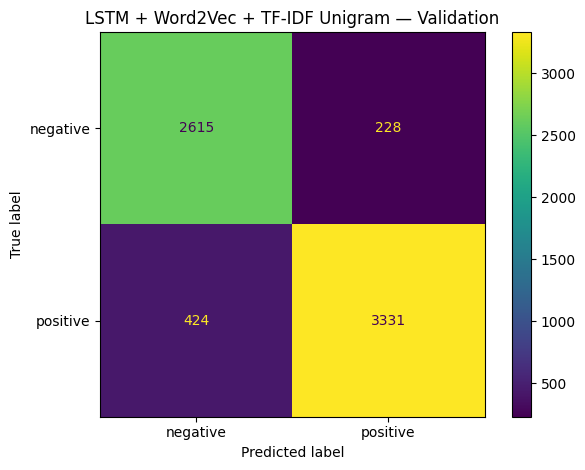


Training: Unigram_Bigram


Model: "lstm_word2vec_tfidf_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_embedding  │ (None, 80, 300)   │  6,446,400 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 80, 300)   │          0 │ word2vec_embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_branch (LSTM)  │ (None, 128)       │    219,648 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ lstm_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     12,352 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,703,745 (25.57 MB)

 Trainable params: 6,703,489 (25.57 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7953 - loss: 0.4313 - precision: 0.8642 - recall: 0.7528
Epoch 1: val_loss improved from None to 0.24780, saving model to /content/lstm_hybrid_models/Unigram_Bigram.keras

Epoch 1: finished saving model to /content/lstm_hybrid_models/Unigram_Bigram.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.8528 - loss: 0.3458 - precision: 0.9086 - recall: 0.8242 - val_accuracy: 0.9019 - val_loss: 0.2478 - val_precision: 0.9412 - val_recall: 0.8828 - learning_rate: 0.0010
Epoch 2/15
412/413 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8965 - loss: 0.2629 - precision: 0.9380 - recall: 0.8763
Epoch 2: val_loss improved from 0.24780 to 0.23541, saving model to /content/lstm_hybrid_models/Unigram_Bigram.keras

Epoch 2: finished saving model to /content/lstm_hybrid_models/Unigram_Bigram.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9010 - loss: 0.2543 - precision: 0.9412 - recall: 0.8812 - val_accuracy:

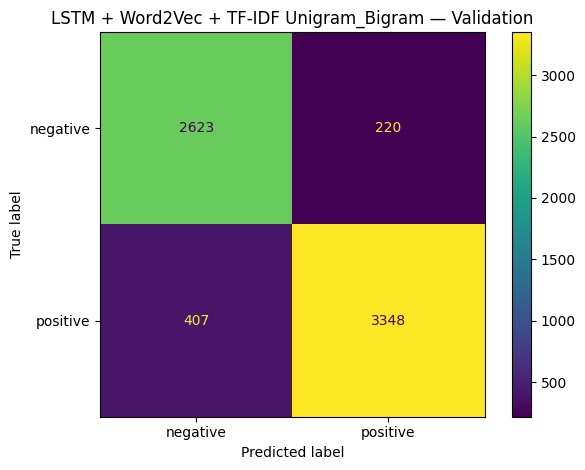


Training: Unigram_Bigram_Trigram


Model: "lstm_word2vec_tfidf_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_embedding  │ (None, 80, 300)   │  6,446,400 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 80, 300)   │          0 │ word2vec_embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_branch (LSTM)  │ (None, 128)       │    219,648 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ lstm_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     12,352 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,703,745 (25.57 MB)

 Trainable params: 6,703,489 (25.57 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7990 - loss: 0.4263 - precision: 0.8655 - recall: 0.7599
Epoch 1: val_loss improved from None to 0.25758, saving model to /content/lstm_hybrid_models/Unigram_Bigram_Trigram.keras

Epoch 1: finished saving model to /content/lstm_hybrid_models/Unigram_Bigram_Trigram.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8559 - loss: 0.3402 - precision: 0.9090 - recall: 0.8298 - val_accuracy: 0.8991 - val_loss: 0.2576 - val_precision: 0.9476 - val_recall: 0.8708 - learning_rate: 0.0010
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8981 - loss: 0.2638 - precision: 0.9364 - recall: 0.8810
Epoch 2: val_loss improved from 0.25758 to 0.23869, saving model to /content/lstm_hybrid_models/Unigram_Bigram_Trigram.keras

Epoch 2: finished saving model to /content/lstm_hybrid_models/Unigram_Bigram_Trigram.keras
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9020 - loss: 0.2567 - precision: 0.9395 

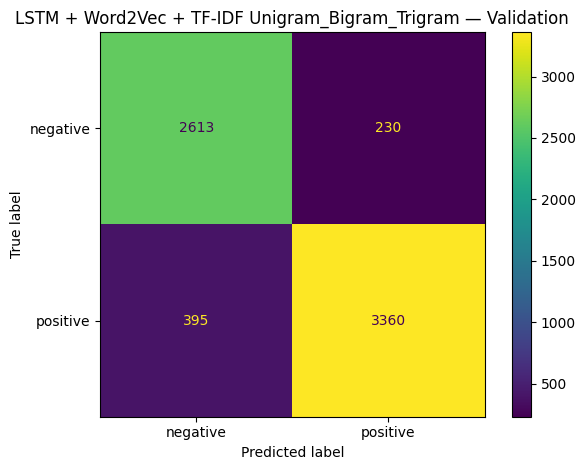

In [ ]:
LSTM_MODEL_FOLDER = (
    "/content/lstm_hybrid_models"
)

os.makedirs(
    LSTM_MODEL_FOLDER,
    exist_ok=True,
)

lstm_results = {}


for variant_name, configuration in (
    TFIDF_VARIANTS.items()
):
    print("\n" + "=" * 70)
    print("Training:", variant_name)
    print("=" * 70)

    tf.keras.backend.clear_session()
    gc.collect()

    tfidf_branch_data = prepare_tfidf_branch(
        ngram_range=(
            configuration["ngram_range"]
        ),
        max_features=(
            configuration["max_features"]
        ),
    )

    model = build_lstm_tfidf_hybrid(
        tfidf_dimension=(
            tfidf_branch_data["train"]
            .shape[1]
        )
    )

    model.summary()

    model_path = os.path.join(
        LSTM_MODEL_FOLDER,
        f"{variant_name}.keras",
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        {
            "sequence_input": (
                X_train_sequence
            ),
            "tfidf_input": (
                tfidf_branch_data["train"]
            ),
        },
        y_train,
        validation_data=(
            {
                "sequence_input": (
                    X_validation_sequence
                ),
                "tfidf_input": (
                    tfidf_branch_data[
                        "validation"
                    ]
                ),
            },
            y_validation,
        ),
        epochs=15,
        batch_size=128,
        class_weight=CLASS_WEIGHT_DICT,
        callbacks=callbacks,
        verbose=1,
    )

    validation_probabilities = (
        model.predict(
            {
                "sequence_input": (
                    X_validation_sequence
                ),
                "tfidf_input": (
                    tfidf_branch_data[
                        "validation"
                    ]
                ),
            },
            batch_size=256,
            verbose=0,
        )
        .ravel()
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(np.int32)

    validation_metrics = (
        evaluate_binary_model(
            y_validation,
            validation_predictions,
            title=(
                "LSTM + Word2Vec + "
                f"TF-IDF {variant_name} "
                "— Validation"
            ),
        )
    )

    lstm_results[variant_name] = {
        "configuration": configuration,
        "model_path": model_path,
        "validation_metrics": (
            validation_metrics
        ),
        "tfidf_branch_data": (
            tfidf_branch_data
        ),
        "history": history.history,
    }

    del model
    gc.collect()

Each TF-IDF representation is trained seperately with the same:
* Word2Vec Embedding Matrix
* LSTM Architecture
* Training, Validation and Test Split
* Class Weights
* Training Parameters

**EarlyStopping** stops training when validation loss no longer improves and restores the best weights, while **ReduceLROnPlateau** lowers the learning rate when progress slows.

## **Compare LSTM Hyrbid Validation Results**

In [ ]:
lstm_validation_summary = pd.DataFrame(
    [
        {
            "Hybrid Model": (
                "LSTM + Word2Vec + "
                f"TF-IDF {variant_name}"
            ),
            "Accuracy": (
                result["validation_metrics"]
                ["accuracy"]
            ),
            "Weighted F1": (
                result["validation_metrics"]
                ["f1_weighted"]
            ),
            "Macro F1": (
                result["validation_metrics"]
                ["f1_macro"]
            ),
        }
        for variant_name, result
        in lstm_results.items()
    ]
).sort_values(
    by="Weighted F1",
    ascending=False,
)

display(lstm_validation_summary)

,Hybrid Model,Accuracy,Weighted F1,Macro F1
2,LSTM + Word2Vec + TF-IDF Unigram_Bigram_Trigram,0.905274,0.905546,0.904044
1,LSTM + Word2Vec + TF-IDF Unigram_Bigram,0.904971,0.905271,0.903810
0,LSTM + Word2Vec + TF-IDF Unigram,0.901182,0.901505,0.900005


# **Test Set Evaluation**

## **Import Libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from IPython.display import display

from scipy.sparse import (
    hstack,
    csr_matrix
)

from scipy.stats import binomtest

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Test-evaluation libraries imported successfully.")

Test-evaluation libraries imported successfully.


In [ ]:
BEST_LR_EMBEDDING = "Word2Vec"

BEST_LSTM_VARIANT = (
    "Unigram_Bigram_Trigram"
)


best_lr_hybrid_result = (
    lr_results[
        BEST_LR_EMBEDDING
    ]
)

best_lstm_hybrid_result = (
    lstm_results[
        BEST_LSTM_VARIANT
    ]
)


print(
    "Selected Logistic Regression hybrid:",
    "TF-IDF (1,3) + Word2Vec"
)

print(
    "Best Logistic Regression C:",
    best_lr_hybrid_result["best_c"]
)


print(
    "\nSelected LSTM hybrid:",
    "Word2Vec + TF-IDF Unigram + Bigram + Trigram"
)

print(
    "Saved LSTM model:",
    best_lstm_hybrid_result["model_path"]
)

Selected Logistic Regression hybrid: TF-IDF (1,3) + Word2Vec
Best Logistic Regression C: 1.0

Selected LSTM hybrid: Word2Vec + TF-IDF Unigram + Bigram + Trigram
Saved LSTM model: /content/lstm_hybrid_models/Unigram_Bigram_Trigram.keras


## **Prepare Logistic Regression Hybird Test Input**

In [ ]:
# Retrieve the Logistic Regression model selected by validation.
best_lr_hybrid_model = (
    best_lr_hybrid_result[
        "model"
    ]
)


# Retrieve the scaler fitted on the training Word2Vec vectors.
best_lr_embedding_scaler = (
    best_lr_hybrid_result[
        "scaler"
    ]
)


# Transform the Word2Vec test vectors using the
# training-fitted scaler.
X_test_word2vec_scaled = (
    best_lr_embedding_scaler.transform(
        embedding_matrices[
            "Word2Vec"
        ]["test"]
    )
    .astype(np.float32)
)


# Combine the TF-IDF unigram–trigram test matrix
# with the scaled Word2Vec test vectors.
X_test_lr_hybrid = hstack(
    [
        X_test_tfidf_123,

        csr_matrix(
            X_test_word2vec_scaled
        )
    ],

    format="csr"
)


print(
    "TF-IDF test shape:",
    X_test_tfidf_123.shape
)

print(
    "Word2Vec test shape:",
    X_test_word2vec_scaled.shape
)

print(
    "Combined Logistic Regression hybrid shape:",
    X_test_lr_hybrid.shape
)

print(
    "Number of test labels:",
    len(y_test)
)

TF-IDF test shape: (6598, 20000)
Word2Vec test shape: (6598, 300)
Combined Logistic Regression hybrid shape: (6598, 20300)
Number of test labels: 6598


## **Logistic Regression Hybrid Test Predictions**

In [ ]:
y_test_pred_lr_hybrid = (
    best_lr_hybrid_model.predict(
        X_test_lr_hybrid
    )
)


lr_hybrid_test_probabilities = (
    best_lr_hybrid_model.predict_proba(
        X_test_lr_hybrid
    )
)


# Find which probability column represents class 1,
# where 1 means positive.
lr_positive_column = int(
    np.where(
        best_lr_hybrid_model.classes_
        == 1
    )[0][0]
)


lr_hybrid_positive_probability = (
    lr_hybrid_test_probabilities[
        :,
        lr_positive_column
    ]
)


lr_hybrid_test_confidence = np.max(
    lr_hybrid_test_probabilities,
    axis=1
)


print(
    "Logistic Regression hybrid predictions completed:",
    len(y_test_pred_lr_hybrid)
)

print(
    "Average prediction confidence:",
    round(
        float(
            lr_hybrid_test_confidence.mean()
        ),
        4
    )
)

Logistic Regression hybrid predictions completed: 6598
Average prediction confidence: 0.8818


## **Load the Selected LSTM Hybrid Model**

In [ ]:
best_lstm_model_path = (
    best_lstm_hybrid_result[
        "model_path"
    ]
)


if not os.path.exists(
    best_lstm_model_path
):
    raise FileNotFoundError(
        "The selected LSTM model file was not found. "
        "Run the earlier LSTM hybrid training cells first.\n"
        f"Expected location: {best_lstm_model_path}"
    )


best_lstm_hybrid_model = (
    tf.keras.models.load_model(
        best_lstm_model_path
    )
)


print(
    "Selected LSTM hybrid model loaded from:"
)

print(
    best_lstm_model_path
)


best_lstm_hybrid_model.summary()

Selected LSTM hybrid model loaded from:
/content/lstm_hybrid_models/Unigram_Bigram_Trigram.keras


Model: "lstm_word2vec_tfidf_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_embedding  │ (None, 80, 300)   │  6,446,400 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 80, 300)   │          0 │ word2vec_embeddi… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_branch (LSTM)  │ (None, 128)       │    219,648 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ lstm_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     12,352 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,110,725 (76.72 MB)

 Trainable params: 6,703,489 (25.57 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 13,406,980 (51.14 MB)

* During validation, **ModelCheckpoint** saved the model with the lowest validation loss.

* This cell loads that saved model instead of using the model from the final training epoch. This is important because the final epoch is not always the strongest validation checkpoint.

## **Prepare LSTM Hyrbid Test Inputs**

In [ ]:
# The sequence input was already produced using the
# training-fitted TextVectorization layer.
X_test_lstm_sequence = (
    X_test_sequence
)


# Retrieve the TF-IDF test branch belonging to the selected
# unigram + bigram + trigram variant.
X_test_lstm_tfidf = (
    best_lstm_hybrid_result[
        "tfidf_branch_data"
    ]["test"]
)


assert (
    X_test_lstm_sequence.shape[0]
    == X_test_lstm_tfidf.shape[0]
    == len(y_test)
)


print(
    "LSTM sequence test shape:",
    X_test_lstm_sequence.shape
)

print(
    "Reduced TF-IDF test shape:",
    X_test_lstm_tfidf.shape
)

print(
    "Test label shape:",
    y_test.shape
)

LSTM sequence test shape: (6598, 80)
Reduced TF-IDF test shape: (6598, 128)
Test label shape: (6598,)


## **LSTM Hybrid Test Predictions**

In [ ]:
lstm_hybrid_positive_probability = (
    best_lstm_hybrid_model.predict(
        {
            "sequence_input":
                X_test_lstm_sequence,

            "tfidf_input":
                X_test_lstm_tfidf
        },

        batch_size=256,

        verbose=1
    )
    .ravel()
)


# Use the same 0.50 decision threshold as validation.
y_test_pred_lstm_hybrid = (
    lstm_hybrid_positive_probability
    >= 0.50
).astype(np.int32)


# Confidence is the probability of the selected class.
lstm_hybrid_test_confidence = np.maximum(

    lstm_hybrid_positive_probability,

    1.0
    - lstm_hybrid_positive_probability
)


print(
    "LSTM hybrid predictions completed:",
    len(y_test_pred_lstm_hybrid)
)

print(
    "Average prediction confidence:",
    round(
        float(
            lstm_hybrid_test_confidence.mean()
        ),
        4
    )
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
LSTM hybrid predictions completed: 6598
Average prediction confidence: 0.8958


## **Calculate Final Test Metrics**

In [ ]:
def calculate_hybrid_test_metrics(
    model_name,
    y_true,
    y_pred,
    positive_probability
):
    """
    Calculate the main binary classification metrics.
    """

    return {
        "Model": model_name,

        "Test Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Weighted Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            positive_probability
        )
    }


lr_hybrid_test_metrics = (
    calculate_hybrid_test_metrics(

        model_name=(
            "Logistic Regression + "
            "TF-IDF UBT + Word2Vec"
        ),

        y_true=y_test,

        y_pred=y_test_pred_lr_hybrid,

        positive_probability=(
            lr_hybrid_positive_probability
        )
    )
)


lstm_hybrid_test_metrics = (
    calculate_hybrid_test_metrics(

        model_name=(
            "LSTM + Word2Vec + "
            "TF-IDF UBT"
        ),

        y_true=y_test,

        y_pred=y_test_pred_lstm_hybrid,

        positive_probability=(
            lstm_hybrid_positive_probability
        )
    )
)


hybrid_test_summary = pd.DataFrame(
    [
        lr_hybrid_test_metrics,
        lstm_hybrid_test_metrics
    ]
)


display(
    hybrid_test_summary.round(4)
)

,Model,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,ROC-AUC
0,Logistic Regression + TF-IDF UBT + Word2Vec,0.9042,0.9073,0.9042,0.9046,0.9032,0.9550
1,LSTM + Word2Vec + TF-IDF UBT,0.9069,0.9089,0.9069,0.9072,0.9058,0.9605


The metrices include:
* **Accuracy**: Overall proportion of correct predictions.
* **Weighted Precision**: Precision while considering the class sizes.
* **Weighted Recall**: Recall while considering the class sizes.
* **Weighted F1-Score**: Balance between precision and recall, weighted by class size.
* **Macro F1-Score**: Gives negative and positive classes equal importance.
* **ROC-AUC**: Measures separation between positive and negative prediction scores.

## **Validation and Test Comparison**

In [ ]:
hybrid_validation_test_comparison = pd.DataFrame({

    "Model": [
        (
            "Logistic Regression + "
            "TF-IDF UBT + Word2Vec"
        ),

        (
            "LSTM + Word2Vec + "
            "TF-IDF UBT"
        )
    ],

    "Validation Accuracy": [
        best_lr_hybrid_result[
            "validation_metrics"
        ]["accuracy"],

        best_lstm_hybrid_result[
            "validation_metrics"
        ]["accuracy"]
    ],

    "Test Accuracy": [
        lr_hybrid_test_metrics[
            "Test Accuracy"
        ],

        lstm_hybrid_test_metrics[
            "Test Accuracy"
        ]
    ],

    "Validation Weighted F1": [
        best_lr_hybrid_result[
            "validation_metrics"
        ]["f1_weighted"],

        best_lstm_hybrid_result[
            "validation_metrics"
        ]["f1_weighted"]
    ],

    "Test Weighted F1": [
        lr_hybrid_test_metrics[
            "Weighted F1"
        ],

        lstm_hybrid_test_metrics[
            "Weighted F1"
        ]
    ]
})


hybrid_validation_test_comparison[
    "Accuracy Change (pp)"
] = (

    hybrid_validation_test_comparison[
        "Test Accuracy"
    ]

    -

    hybrid_validation_test_comparison[
        "Validation Accuracy"
    ]

) * 100


hybrid_validation_test_comparison[
    "Weighted F1 Change (pp)"
] = (

    hybrid_validation_test_comparison[
        "Test Weighted F1"
    ]

    -

    hybrid_validation_test_comparison[
        "Validation Weighted F1"
    ]

) * 100


display(
    hybrid_validation_test_comparison.round(4)
)

,Model,Validation Accuracy,Test Accuracy,Validation Weighted F1,Test Weighted F1,Accuracy Change (pp),Weighted F1 Change (pp)
0,Logistic Regression + TF-IDF UBT + Word2Vec,0.9032,0.9042,0.9035,0.9046,0.1061,0.1060
1,LSTM + Word2Vec + TF-IDF UBT,0.9053,0.9069,0.9055,0.9072,0.1667,0.1681


## **Validation and Test Comparison Chart**

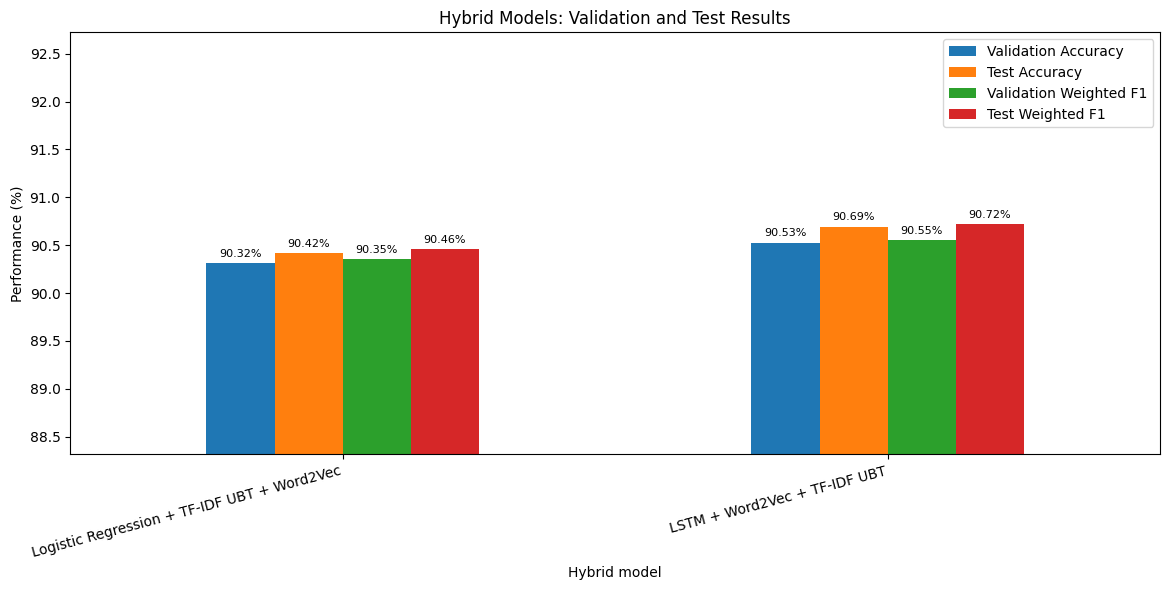

In [ ]:
comparison_plot = (
    hybrid_validation_test_comparison[
        [
            "Model",
            "Validation Accuracy",
            "Test Accuracy",
            "Validation Weighted F1",
            "Test Weighted F1"
        ]
    ]
    .set_index("Model")
    .mul(100)
)


axis = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)


all_values = comparison_plot.to_numpy()


axis.set_ylim(
    max(
        0,
        all_values.min() - 2
    ),

    min(
        100,
        all_values.max() + 2
    )
)


axis.set_title(
    "Hybrid Models: Validation and Test Results"
)

axis.set_xlabel(
    "Hybrid model"
)

axis.set_ylabel(
    "Performance (%)"
)

plt.xticks(
    rotation=15,
    ha="right"
)


for container in axis.containers:

    axis.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=8
    )


plt.tight_layout()
plt.show()

## **Test Classification Reports**

In [ ]:
CLASS_NAMES = [
    "negative",
    "positive"
]


print(
    "=== LOGISTIC REGRESSION HYBRID "
    "TEST CLASSIFICATION REPORT ===\n"
)


print(
    classification_report(
        y_test,
        y_test_pred_lr_hybrid,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


print(
    "\n=== LSTM HYBRID "
    "TEST CLASSIFICATION REPORT ===\n"
)


print(
    classification_report(
        y_test,
        y_test_pred_lstm_hybrid,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


lr_hybrid_report_df = pd.DataFrame(

    classification_report(
        y_test,
        y_test_pred_lr_hybrid,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

).transpose()


lstm_hybrid_report_df = pd.DataFrame(

    classification_report(
        y_test,
        y_test_pred_lstm_hybrid,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

).transpose()

=== LOGISTIC REGRESSION HYBRID TEST CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    negative     0.8588    0.9307    0.8933      2843
    positive     0.9440    0.8842    0.9131      3755

    accuracy                         0.9042      6598
   macro avg     0.9014    0.9074    0.9032      6598
weighted avg     0.9073    0.9042    0.9046      6598


=== LSTM HYBRID TEST CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    negative     0.8687    0.9237    0.8953      2843
    positive     0.9393    0.8943    0.9162      3755

    accuracy                         0.9069      6598
   macro avg     0.9040    0.9090    0.9058      6598
weighted avg     0.9089    0.9069    0.9072      6598



## **Confusion Matrices**

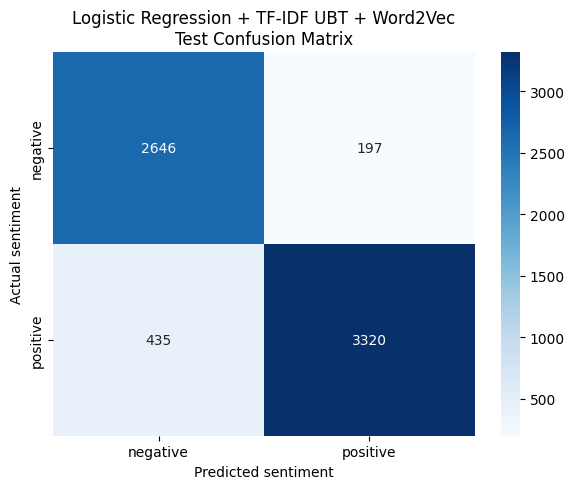

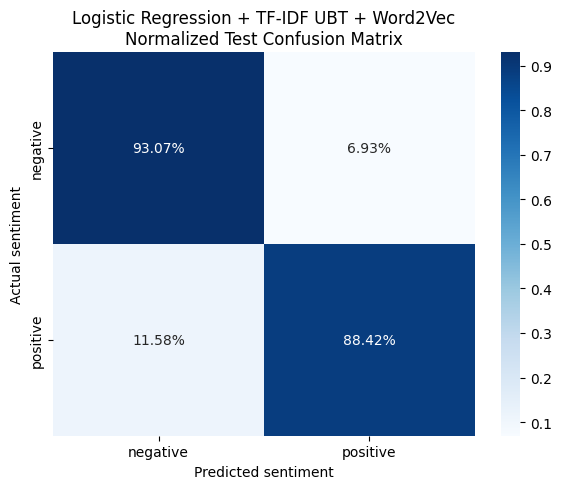

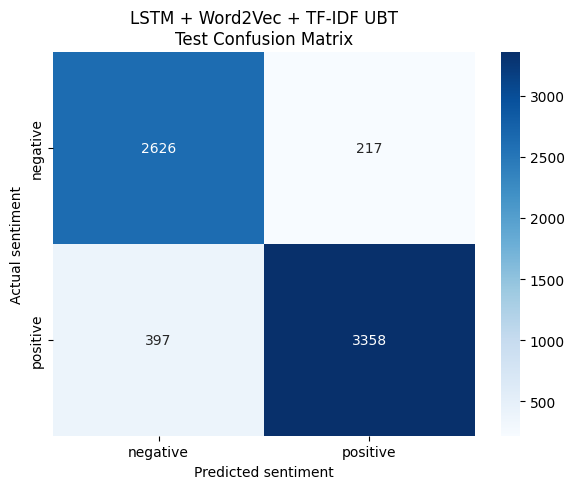

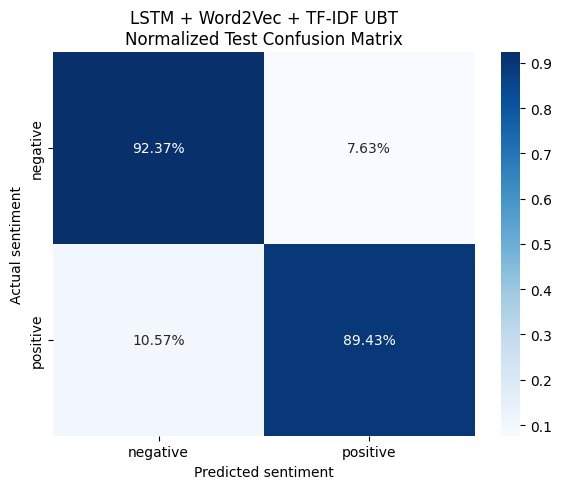

In [ ]:
def show_hybrid_confusion_matrices(
    y_true,
    y_pred,
    model_name
):
    """
    Display count and normalized confusion matrices.
    """

    count_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )


    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        count_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        f"{model_name}\n"
        "Test Confusion Matrix"
    )

    plt.xlabel(
        "Predicted sentiment"
    )

    plt.ylabel(
        "Actual sentiment"
    )

    plt.tight_layout()
    plt.show()


    normalized_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
        normalize="true"
    )


    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        normalized_matrix,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        f"{model_name}\n"
        "Normalized Test Confusion Matrix"
    )

    plt.xlabel(
        "Predicted sentiment"
    )

    plt.ylabel(
        "Actual sentiment"
    )

    plt.tight_layout()
    plt.show()


    return (
        count_matrix,
        normalized_matrix
    )


(
    lr_hybrid_confusion_matrix,
    lr_hybrid_normalized_cm
) = show_hybrid_confusion_matrices(

    y_true=y_test,

    y_pred=y_test_pred_lr_hybrid,

    model_name=(
        "Logistic Regression + "
        "TF-IDF UBT + Word2Vec"
    )
)


(
    lstm_hybrid_confusion_matrix,
    lstm_hybrid_normalized_cm
) = show_hybrid_confusion_matrices(

    y_true=y_test,

    y_pred=y_test_pred_lstm_hybrid,

    model_name=(
        "LSTM + Word2Vec + TF-IDF UBT"
    )
)

## **Detailed Test-Prediction Tables**

In [ ]:
def build_hybrid_prediction_table(
    model_name,
    predictions,
    positive_probability,
    confidence
):
    """
    Create one detailed row for every test review.
    """

    result = pd.DataFrame({

        "test_row":
            np.arange(
                len(y_test)
            ),

        "global_index_id":
            test_df[
                "global_index_id"
            ].to_numpy(),

        "tfidf_review_text":
            test_df[
                "text_tfidf"
            ].astype(str).to_numpy(),

        "embedding_review_text":
            test_df[
                "text_embedding"
            ].astype(str).to_numpy(),

        "actual_encoded":
            y_test,

        "predicted_encoded":
            predictions,

        "actual_sentiment":
            np.where(
                y_test == 1,
                "positive",
                "negative"
            ),

        "predicted_sentiment":
            np.where(
                predictions == 1,
                "positive",
                "negative"
            ),

        "positive_probability":
            positive_probability,

        "confidence":
            confidence,

        "model":
            model_name
    })


    result[
        "correct_prediction"
    ] = (

        result[
            "actual_encoded"
        ]

        ==

        result[
            "predicted_encoded"
        ]
    )


    result[
        "error_type"
    ] = np.where(

        result[
            "correct_prediction"
        ],

        "Correct",

        result[
            "actual_sentiment"
        ]

        + " → "

        + result[
            "predicted_sentiment"
        ]
    )


    result[
        "word_count"
    ] = (

        result[
            "embedding_review_text"
        ]

        .str.split()

        .str.len()
    )


    return result


lr_hybrid_predictions_df = (
    build_hybrid_prediction_table(

        model_name=(
            "Logistic Regression + "
            "TF-IDF UBT + Word2Vec"
        ),

        predictions=(
            y_test_pred_lr_hybrid
        ),

        positive_probability=(
            lr_hybrid_positive_probability
        ),

        confidence=(
            lr_hybrid_test_confidence
        )
    )
)


lstm_hybrid_predictions_df = (
    build_hybrid_prediction_table(

        model_name=(
            "LSTM + Word2Vec + TF-IDF UBT"
        ),

        predictions=(
            y_test_pred_lstm_hybrid
        ),

        positive_probability=(
            lstm_hybrid_positive_probability
        ),

        confidence=(
            lstm_hybrid_test_confidence
        )
    )
)


print(
    "Logistic Regression hybrid predictions:"
)

display(
    lr_hybrid_predictions_df.head(10)
)


print(
    "\nLSTM hybrid predictions:"
)

display(
    lstm_hybrid_predictions_df.head(10)
)

Logistic Regression hybrid predictions:


,test_row,global_index_id,tfidf_review_text,embedding_review_text,actual_encoded,predicted_encoded,actual_sentiment,predicted_sentiment,positive_probability,confidence,model,correct_prediction,error_type,word_count
0,0,review_47430,i love this app because i can listen to my fav...,i love this app because i can listen to my fav...,1,1,positive,positive,0.996521,0.996521,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,16
1,1,review_45723,"gave me an ad for 30 mins. of ad free music, b...","gave me an ad for 30 mins. of ad free music, b...",0,0,negative,negative,0.084332,0.915668,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,22
2,2,review_24653,much love. this app is my favorite when it com...,much love. this app is my favorite when it com...,1,1,positive,positive,0.996523,0.996523,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,24
3,3,review_57177,i do heavily enjoy spotify - the fact of free ...,i do heavily enjoy spotify - the fact of free ...,1,1,positive,positive,0.917217,0.917217,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,52
4,4,review_42569,love the new and the old songs in the past. br...,love the new and the old songs in the past. br...,1,1,positive,positive,0.928259,0.928259,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,37
5,5,review_48294,i cannot shuffle through my own liked songs at...,i cannot shuffle through my own liked songs at...,0,0,negative,negative,0.073574,0.926426,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,43
6,6,review_26111,great array of good music,great array of good music,1,1,positive,positive,0.999793,0.999793,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,5
7,7,review_63898,they know my taste of music and always made a ...,they know my taste of music and always made a ...,1,1,positive,positive,0.896484,0.896484,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,14
8,8,review_29809,for years the app was basically flawless. howe...,for years the app was basically flawless. howe...,0,0,negative,negative,0.054345,0.945655,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,85
9,9,review_41611,real awesome. love how at the end of the year ...,real awesome. love how at the end of the year ...,1,1,positive,positive,0.871573,0.871573,Logistic Regression + TF-IDF UBT + Word2Vec,True,Correct,94



LSTM hybrid predictions:


,test_row,global_index_id,tfidf_review_text,embedding_review_text,actual_encoded,predicted_encoded,actual_sentiment,predicted_sentiment,positive_probability,confidence,model,correct_prediction,error_type,word_count
0,0,review_47430,i love this app because i can listen to my fav...,i love this app because i can listen to my fav...,1,1,positive,positive,0.996433,0.996433,LSTM + Word2Vec + TF-IDF UBT,True,Correct,16
1,1,review_45723,"gave me an ad for 30 mins. of ad free music, b...","gave me an ad for 30 mins. of ad free music, b...",0,0,negative,negative,0.201748,0.798252,LSTM + Word2Vec + TF-IDF UBT,True,Correct,22
2,2,review_24653,much love. this app is my favorite when it com...,much love. this app is my favorite when it com...,1,1,positive,positive,0.998954,0.998954,LSTM + Word2Vec + TF-IDF UBT,True,Correct,24
3,3,review_57177,i do heavily enjoy spotify - the fact of free ...,i do heavily enjoy spotify - the fact of free ...,1,1,positive,positive,0.934932,0.934932,LSTM + Word2Vec + TF-IDF UBT,True,Correct,52
4,4,review_42569,love the new and the old songs in the past. br...,love the new and the old songs in the past. br...,1,1,positive,positive,0.993449,0.993449,LSTM + Word2Vec + TF-IDF UBT,True,Correct,37
5,5,review_48294,i cannot shuffle through my own liked songs at...,i cannot shuffle through my own liked songs at...,0,0,negative,negative,0.072204,0.927796,LSTM + Word2Vec + TF-IDF UBT,True,Correct,43
6,6,review_26111,great array of good music,great array of good music,1,1,positive,positive,0.997354,0.997354,LSTM + Word2Vec + TF-IDF UBT,True,Correct,5
7,7,review_63898,they know my taste of music and always made a ...,they know my taste of music and always made a ...,1,1,positive,positive,0.989672,0.989672,LSTM + Word2Vec + TF-IDF UBT,True,Correct,14
8,8,review_29809,for years the app was basically flawless. howe...,for years the app was basically flawless. howe...,0,0,negative,negative,0.068749,0.931251,LSTM + Word2Vec + TF-IDF UBT,True,Correct,85
9,9,review_41611,real awesome. love how at the end of the year ...,real awesome. love how at the end of the year ...,1,1,positive,positive,0.975332,0.975332,LSTM + Word2Vec + TF-IDF UBT,True,Correct,94


## **Show Confident Incorrect Predictions**

In [ ]:
lr_hybrid_wrong_predictions = (

    lr_hybrid_predictions_df[

        ~lr_hybrid_predictions_df[
            "correct_prediction"
        ]

    ]

    .sort_values(
        "confidence",
        ascending=False
    )

    .reset_index(drop=True)
)


lstm_hybrid_wrong_predictions = (

    lstm_hybrid_predictions_df[

        ~lstm_hybrid_predictions_df[
            "correct_prediction"
        ]

    ]

    .sort_values(
        "confidence",
        ascending=False
    )

    .reset_index(drop=True)
)


print(
    "Most confident Logistic Regression hybrid errors:"
)

display(

    lr_hybrid_wrong_predictions.head(20)[

        [
            "embedding_review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "positive_probability",
            "confidence",
            "error_type"
        ]

    ]
)


print(
    "\nMost confident LSTM hybrid errors:"
)

display(

    lstm_hybrid_wrong_predictions.head(20)[

        [
            "embedding_review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "positive_probability",
            "confidence",
            "error_type"
        ]

    ]
)

Most confident Logistic Regression hybrid errors:


,embedding_review_text,actual_sentiment,predicted_sentiment,positive_probability,confidence,error_type
0,best,negative,positive,1.000000,1.000000,negative → positive
1,perfect,negative,positive,0.999999,0.999999,negative → positive
2,best playing music 🎶 👌 ever from the playlist ...,negative,positive,0.999721,0.999721,negative → positive
3,i love it❤ i like it so much 💙💚💛💜💝,negative,positive,0.999116,0.999116,negative → positive
4,best for listening,negative,positive,0.997849,0.997849,negative → positive
5,very good app,negative,positive,0.997193,0.997193,negative → positive
6,good app but still missing on many great music...,negative,positive,0.996162,0.996162,negative → positive
7,the app is too much good for song😊😊😊😊😚😚😚❤️❤️❤️...,negative,positive,0.994974,0.994974,negative → positive
8,nice 👍,negative,positive,0.994850,0.994850,negative → positive
9,terrible it does not even let me play the song...,positive,negative,0.005565,0.994435,positive → negative



Most confident LSTM hybrid errors:


,embedding_review_text,actual_sentiment,predicted_sentiment,positive_probability,confidence,error_type
0,best playing music 🎶 👌 ever from the playlist ...,negative,positive,0.998942,0.998942,negative → positive
1,definitely the best music streaming app. upd: ...,negative,positive,0.998882,0.998882,negative → positive
2,i love it❤ i like it so much 💙💚💛💜💝,negative,positive,0.998392,0.998392,negative → positive
3,app is easy to use and the music is best .,negative,positive,0.997651,0.997651,negative → positive
4,best,negative,positive,0.994564,0.994564,negative → positive
5,very good app,negative,positive,0.994345,0.994345,negative → positive
6,lots of ads. few yrs back spotify is the best ...,negative,positive,0.994233,0.994233,negative → positive
7,good app but still missing on many great music...,negative,positive,0.993618,0.993618,negative → positive
8,the app is too much good for song😊😊😊😊😚😚😚❤️❤️❤️...,negative,positive,0.992935,0.992935,negative → positive
9,terrible it does not even let me play the song...,positive,negative,0.009517,0.990483,positive → negative


## **Performance By Review Length**

In [ ]:
def create_length_summary(
    prediction_table
):
    result = prediction_table.copy()


    result[
        "review_length_group"
    ] = pd.cut(

        result[
            "word_count"
        ],

        bins=[
            -1,
            1,
            3,
            6,
            10,
            20,
            40,
            np.inf
        ],

        labels=[
            "1 word",
            "2–3 words",
            "4–6 words",
            "7–10 words",
            "11–20 words",
            "21–40 words",
            "More than 40 words"
        ]
    )


    summary = (

        result

        .groupby(
            "review_length_group",
            observed=False
        )

        .agg(

            review_count=(
                "correct_prediction",
                "size"
            ),

            accuracy=(
                "correct_prediction",
                "mean"
            ),

            average_confidence=(
                "confidence",
                "mean"
            ),

            average_word_count=(
                "word_count",
                "mean"
            )
        )

        .reset_index()
    )


    return result, summary


(
    lr_hybrid_length_detail,
    lr_hybrid_length_summary
) = create_length_summary(
    lr_hybrid_predictions_df
)


(
    lstm_hybrid_length_detail,
    lstm_hybrid_length_summary
) = create_length_summary(
    lstm_hybrid_predictions_df
)


print(
    "Logistic Regression hybrid performance "
    "by review length:"
)

display(
    lr_hybrid_length_summary.round(4)
)


print(
    "\nLSTM hybrid performance "
    "by review length:"
)

display(
    lstm_hybrid_length_summary.round(4)
)

Logistic Regression hybrid performance by review length:


,review_length_group,review_count,accuracy,average_confidence,average_word_count
0,1 word,45,0.9111,0.9833,1.0000
1,2–3 words,259,0.8842,0.9409,2.6023
2,4–6 words,496,0.9355,0.9378,5.1190
3,7–10 words,772,0.9430,0.9350,8.4547
4,11–20 words,1572,0.9186,0.8932,15.1559
5,21–40 words,1863,0.8835,0.8548,29.3875
6,More than 40 words,1591,0.8887,0.8466,63.7618



LSTM hybrid performance by review length:


,review_length_group,review_count,accuracy,average_confidence,average_word_count
0,1 word,45,0.9111,0.9406,1.0000
1,2–3 words,259,0.8996,0.9183,2.6023
2,4–6 words,496,0.9355,0.9324,5.1190
3,7–10 words,772,0.9404,0.9348,8.4547
4,11–20 words,1572,0.9122,0.9113,15.1559
5,21–40 words,1863,0.8910,0.8715,29.3875
6,More than 40 words,1591,0.8963,0.8735,63.7618


## **Review-Length Accuracy Plots**

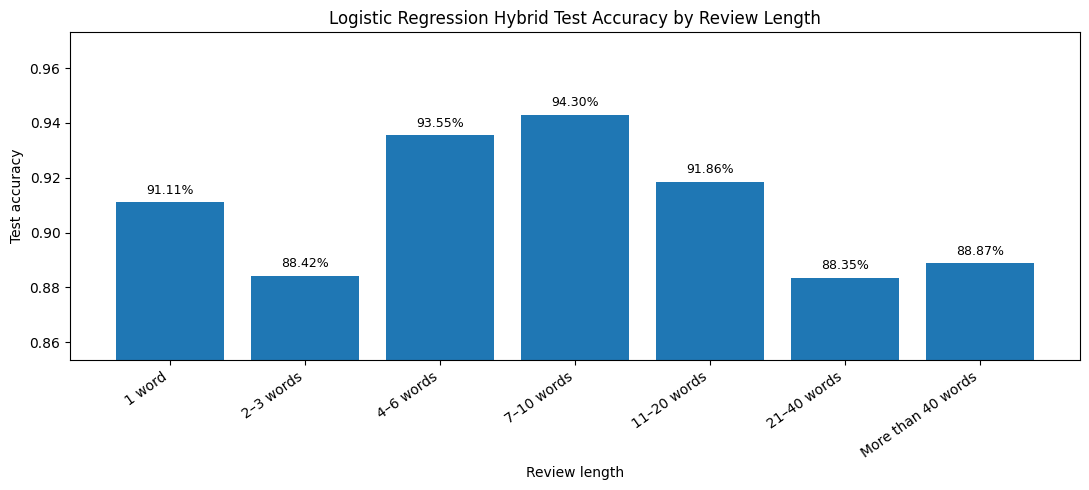

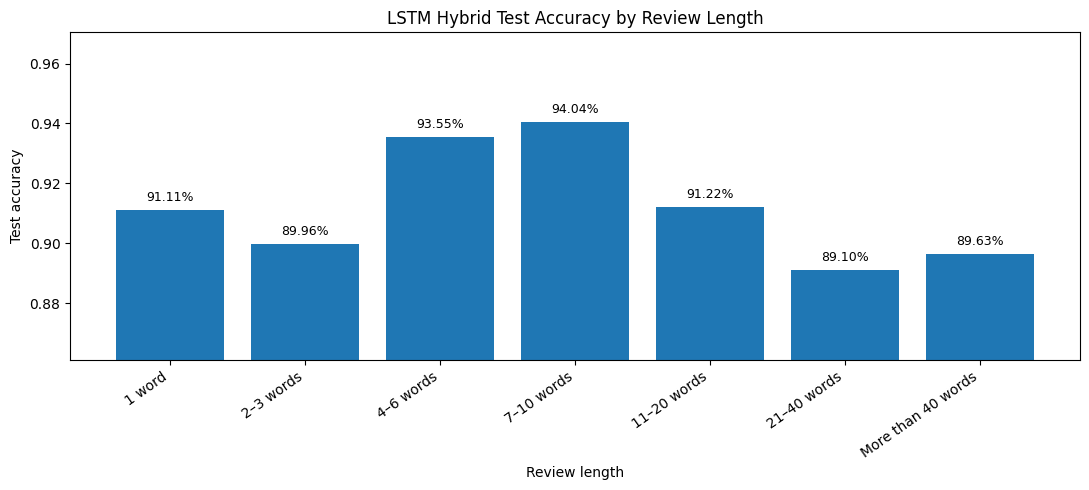

In [ ]:
def plot_length_accuracy(
    length_summary,
    title
):
    plot_data = (

        length_summary

        .dropna(
            subset=["accuracy"]
        )

        .copy()
    )


    values = (
        plot_data[
            "accuracy"
        ]
        .to_numpy()
    )


    y_min = max(
        0,
        values.min() - 0.03
    )


    y_max = min(
        1,
        values.max() + 0.03
    )


    plt.figure(
        figsize=(11, 5)
    )


    bars = plt.bar(

        plot_data[
            "review_length_group"
        ].astype(str),

        values
    )


    plt.ylim(
        y_min,
        y_max
    )


    plt.title(title)

    plt.xlabel(
        "Review length"
    )

    plt.ylabel(
        "Test accuracy"
    )


    plt.xticks(
        rotation=35,
        ha="right"
    )


    for bar, value in zip(
        bars,
        values
    ):

        plt.text(

            bar.get_x()
            + bar.get_width() / 2,

            value + 0.002,

            f"{value * 100:.2f}%",

            ha="center",

            va="bottom",

            fontsize=9
        )


    plt.tight_layout()
    plt.show()


plot_length_accuracy(

    lr_hybrid_length_summary,

    (
        "Logistic Regression Hybrid "
        "Test Accuracy by Review Length"
    )
)


plot_length_accuracy(

    lstm_hybrid_length_summary,

    (
        "LSTM Hybrid "
        "Test Accuracy by Review Length"
    )
)

## **Confidence Analysis**

In [ ]:
def create_confidence_summary(
    prediction_table
):
    result = prediction_table.copy()


    result[
        "confidence_group"
    ] = pd.cut(

        result[
            "confidence"
        ],

        bins=[
            0.50,
            0.60,
            0.70,
            0.80,
            0.90,
            1.000001
        ],

        include_lowest=True,

        labels=[
            "0.50–0.60",
            "0.60–0.70",
            "0.70–0.80",
            "0.80–0.90",
            "0.90–1.00"
        ]
    )


    summary = (

        result

        .groupby(
            "confidence_group",
            observed=False
        )

        .agg(

            prediction_count=(
                "correct_prediction",
                "size"
            ),

            accuracy=(
                "correct_prediction",
                "mean"
            ),

            average_confidence=(
                "confidence",
                "mean"
            )
        )

        .reset_index()
    )


    return summary


lr_hybrid_confidence_summary = (
    create_confidence_summary(
        lr_hybrid_predictions_df
    )
)


lstm_hybrid_confidence_summary = (
    create_confidence_summary(
        lstm_hybrid_predictions_df
    )
)


print(
    "Logistic Regression hybrid confidence analysis:"
)

display(
    lr_hybrid_confidence_summary.round(4)
)


print(
    "\nLSTM hybrid confidence analysis:"
)

display(
    lstm_hybrid_confidence_summary.round(4)
)

Logistic Regression hybrid confidence analysis:


,confidence_group,prediction_count,accuracy,average_confidence
0,0.50–0.60,382,0.5707,0.5512
1,0.60–0.70,444,0.7297,0.6526
2,0.70–0.80,642,0.8302,0.7531
3,0.80–0.90,1139,0.9078,0.8560
4,0.90–1.00,3991,0.9664,0.9671



LSTM hybrid confidence analysis:


,confidence_group,prediction_count,accuracy,average_confidence
0,0.50–0.60,311,0.5691,0.5530
1,0.60–0.70,379,0.7098,0.6514
2,0.70–0.80,532,0.7707,0.7531
3,0.80–0.90,1079,0.8842,0.8581
4,0.90–1.00,4297,0.9714,0.9692


## **Model Agreement and Disagreement**

In [ ]:
lr_correct = (
    y_test_pred_lr_hybrid
    == y_test
)

lstm_correct = (
    y_test_pred_lstm_hybrid
    == y_test
)


agreement_summary = pd.DataFrame({

    "Category": [

        "Both correct",

        "Both incorrect",

        "Logistic Regression correct only",

        "LSTM correct only",

        "Same predicted class",

        "Different predicted class"
    ],

    "Review count": [

        int(
            np.sum(
                lr_correct
                & lstm_correct
            )
        ),

        int(
            np.sum(
                ~lr_correct
                & ~lstm_correct
            )
        ),

        int(
            np.sum(
                lr_correct
                & ~lstm_correct
            )
        ),

        int(
            np.sum(
                ~lr_correct
                & lstm_correct
            )
        ),

        int(
            np.sum(
                y_test_pred_lr_hybrid
                == y_test_pred_lstm_hybrid
            )
        ),

        int(
            np.sum(
                y_test_pred_lr_hybrid
                != y_test_pred_lstm_hybrid
            )
        )
    ]
})


agreement_summary[
    "Percentage"
] = (

    agreement_summary[
        "Review count"
    ]

    / len(y_test)

    * 100
)


display(
    agreement_summary.round(2)
)

,Category,Review count,Percentage
0,Both correct,5843,88.56
1,Both incorrect,491,7.44
2,Logistic Regression correct only,123,1.86
3,LSTM correct only,141,2.14
4,Same predicted class,6334,96.00
5,Different predicted class,264,4.00


This identifies:

* Reviews both hybrids classified correctly.
* Reviews both classified incorrectly.
* Reviews where only one hybrid was correct.
* Reviews where the models produced different predictions.

## **Exact McNemar Comparison**

In [ ]:
lr_only_correct = int(
    np.sum(
        lr_correct
        & ~lstm_correct
    )
)


lstm_only_correct = int(
    np.sum(
        ~lr_correct
        & lstm_correct
    )
)


discordant_total = (
    lr_only_correct
    + lstm_only_correct
)


if discordant_total > 0:

    mcnemar_result = binomtest(

        k=min(
            lr_only_correct,
            lstm_only_correct
        ),

        n=discordant_total,

        p=0.50,

        alternative="two-sided"
    )

    mcnemar_p_value = (
        mcnemar_result.pvalue
    )

else:

    mcnemar_p_value = 1.0


mcnemar_summary = pd.DataFrame({

    "LR correct, LSTM incorrect": [
        lr_only_correct
    ],

    "LR incorrect, LSTM correct": [
        lstm_only_correct
    ],

    "Exact McNemar p-value": [
        mcnemar_p_value
    ]
})


display(
    mcnemar_summary.round(6)
)

,"LR correct, LSTM incorrect","LR incorrect, LSTM correct",Exact McNemar p-value
0,123,141,0.295419


McNemar’s test examines whether the two models have meaningfully different error behaviour on the same test reviews.

* p-value < 0.05
  * the difference in paired errors is statistically significant

* p-value ≥ 0.05
  * the observed difference may be due to normal sample variation

## **Sentiment Distribution**

In [ ]:
def create_sentiment_distribution(
    model_name,
    predictions
):
    positive_count = int(
        np.sum(
            predictions == 1
        )
    )

    negative_count = int(
        np.sum(
            predictions == 0
        )
    )


    positive_percentage = (
        positive_count
        / len(predictions)
        * 100
    )


    negative_percentage = (
        negative_count
        / len(predictions)
        * 100
    )


    return {
        "Model": model_name,

        "Predicted positive count":
            positive_count,

        "Predicted negative count":
            negative_count,

        "Predicted positive percentage":
            positive_percentage,

        "Predicted negative percentage":
            negative_percentage,

        "Net sentiment index":
            positive_percentage
            - negative_percentage
    }


hybrid_sentiment_distribution = pd.DataFrame([

    create_sentiment_distribution(

        (
            "Logistic Regression + "
            "TF-IDF UBT + Word2Vec"
        ),

        y_test_pred_lr_hybrid
    ),


    create_sentiment_distribution(

        (
            "LSTM + Word2Vec + "
            "TF-IDF UBT"
        ),

        y_test_pred_lstm_hybrid
    )
])


display(
    hybrid_sentiment_distribution.round(2)
)

,Model,Predicted positive count,Predicted negative count,Predicted positive percentage,Predicted negative percentage,Net sentiment index
0,Logistic Regression + TF-IDF UBT + Word2Vec,3517,3081,53.30,46.70,6.61
1,LSTM + Word2Vec + TF-IDF UBT,3575,3023,54.18,45.82,8.37


## **Export Hybrid Test Results**

In [ ]:
HYBRID_TEST_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/"
    "spotify_preprocessed_output/"
    "hybrid_test_results"
)


os.makedirs(
    HYBRID_TEST_OUTPUT_FOLDER,
    exist_ok=True
)


HYBRID_TEST_EXCEL_PATH = os.path.join(

    HYBRID_TEST_OUTPUT_FOLDER,

    "hybrid_final_test_evaluation.xlsx"
)


with pd.ExcelWriter(

    HYBRID_TEST_EXCEL_PATH,

    engine="openpyxl"

) as writer:


    hybrid_test_summary.to_excel(

        writer,

        sheet_name="Test Summary",

        index=False
    )


    hybrid_validation_test_comparison.to_excel(

        writer,

        sheet_name="Val Test Comparison",

        index=False
    )


    lr_hybrid_report_df.to_excel(

        writer,

        sheet_name="LR Class Report"
    )


    lstm_hybrid_report_df.to_excel(

        writer,

        sheet_name="LSTM Class Report"
    )


    lr_hybrid_predictions_df.to_excel(

        writer,

        sheet_name="LR Predictions",

        index=False
    )


    lstm_hybrid_predictions_df.to_excel(

        writer,

        sheet_name="LSTM Predictions",

        index=False
    )


    lr_hybrid_wrong_predictions.to_excel(

        writer,

        sheet_name="LR Errors",

        index=False
    )


    lstm_hybrid_wrong_predictions.to_excel(

        writer,

        sheet_name="LSTM Errors",

        index=False
    )


    lr_hybrid_length_summary.to_excel(

        writer,

        sheet_name="LR Length",

        index=False
    )


    lstm_hybrid_length_summary.to_excel(

        writer,

        sheet_name="LSTM Length",

        index=False
    )


    lr_hybrid_confidence_summary.to_excel(

        writer,

        sheet_name="LR Confidence",

        index=False
    )


    lstm_hybrid_confidence_summary.to_excel(

        writer,

        sheet_name="LSTM Confidence",

        index=False
    )


    agreement_summary.to_excel(

        writer,

        sheet_name="Model Agreement",

        index=False
    )


    mcnemar_summary.to_excel(

        writer,

        sheet_name="McNemar Test",

        index=False
    )


    hybrid_sentiment_distribution.to_excel(

        writer,

        sheet_name="Sentiment Distribution",

        index=False
    )


print(
    "Hybrid test evaluation exported to:"
)

print(
    HYBRID_TEST_EXCEL_PATH
)

Hybrid test evaluation exported to:
/content/drive/MyDrive/spotify_preprocessed_output/hybrid_test_results/hybrid_final_test_evaluation.xlsx
